In [1]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import shutil

# Define the device to use (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
# Define transformations for the training and testing sets
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets using ImageFolder
data_dir = 'dataset/Flower_Dataset'

# Check if the data_dir exists
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"The specified data directory '{data_dir}' does not exist.")

# Check the structure of the 'train' directory
train_dir = os.path.join(data_dir, 'train')
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"The training data directory '{train_dir}' does not exist. Please ensure your dataset has a 'train' subfolder.")

# Temporarily load train dataset to get class names and number of classes
try:
    train_image_folder_temp = datasets.ImageFolder(train_dir)
    class_names = train_image_folder_temp.classes
    num_classes = len(class_names)
    if not class_names:
        raise ValueError(f"No class subfolders found in the training directory '{train_dir}'. "
                         "ImageFolder expects data organized as: root/class_name/xxx.jpg")
except Exception as e:
    raise ValueError(f"Error initializing ImageFolder for training data: {e}. "
                     f"Ensure '{train_dir}' contains class subfolders.")

# Check and fix the structure of the 'test' directory
test_dir = os.path.join(data_dir, 'test')
if not os.path.exists(test_dir):
    os.makedirs(test_dir)

# Check if test_dir contains class subfolders or direct images
has_subfolders = any(os.path.isdir(os.path.join(test_dir, d)) for d in os.listdir(test_dir))
has_direct_images = any(os.path.isfile(os.path.join(test_dir, f)) for f in os.listdir(test_dir))

# If test directory has direct images but no subfolders, move them to a dummy class folder
if not has_subfolders and has_direct_images:
    print(f"Warning: The test directory '{test_dir}' contains image files directly, without class subfolders.")
    print("To allow ImageFolder to load the test data, all images will be moved into a single subfolder named 'unknown_class' within the test directory.")
    print("Note that this will make the test set effectively a single class, which might not be suitable for meaningful multi-class classification evaluation.")

    # Create a dummy subfolder
    dummy_class_dir = os.path.join(test_dir, 'unknown_class')
    os.makedirs(dummy_class_dir, exist_ok=True)

    # Move all image files from test_dir to dummy_class_dir
    for item in os.listdir(test_dir):
        item_path = os.path.join(test_dir, item)
        if os.path.isfile(item_path):
            shutil.move(item_path, os.path.join(dummy_class_dir, item))
    print(f"All test images moved to '{dummy_class_dir}'.")
elif not has_subfolders and not has_direct_images:
    print(f"Warning: The test directory '{test_dir}' is empty and contains no class subfolders. "
          "A dummy 'unknown_class' subfolder will be created, but the test set will be empty.")
    dummy_class_dir = os.path.join(test_dir, 'unknown_class')
    os.makedirs(dummy_class_dir, exist_ok=True)


# Load datasets using ImageFolder (now test_dir should have a valid structure)
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test']) # This should now work
}

# Create data loaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}


print(f"Number of training samples: {dataset_sizes['train']}")
print(f"Number of testing samples: {dataset_sizes['test']}")
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

Number of training samples: 2746
Number of testing samples: 924
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [15]:
# Load a pre-trained EfficientNetB0 model
from torchvision.models import EfficientNet_B0_Weights
weights = EfficientNet_B0_Weights.DEFAULT
model_ft = models.efficientnet_b0(weights=weights)

# Freeze all parameters in the feature extractor (all layers except the classifier)
for param in model_ft.parameters():
    param.requires_grad = False

# Replace the final classifier layer
# The EfficientNet classifier typically consists of a dropout layer and a linear layer.
# We need to replace the linear layer (model_ft.classifier[1]).
num_ftrs = model_ft.classifier[1].in_features
model_ft.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), # Keep original dropout or adjust
    nn.Linear(num_ftrs, num_classes)
)

# Move the model to the defined device
model_ft = model_ft.to(device)

print("EfficientNetB0 model initialized and moved to device.")
print(f"Modified final classifier: {model_ft.classifier}")

EfficientNetB0 model initialized and moved to device.
Modified final classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [16]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.classifier.parameters(), lr=0.001)

# Function to train the model for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        with torch.set_grad_enabled(True): # Gradients are enabled for the final layer
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward() # Backpropagation
            optimizer.step() # Optimize weights

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

# Function to evaluate the model for one epoch
def evaluate_one_epoch(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluate mode
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad(): # Disable gradient calculation for evaluation
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

print("Loss function, optimizer, and training/evaluation functions defined.")

Loss function, optimizer, and training/evaluation functions defined.


In [17]:
num_epochs = 20

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("Starting model training...")
for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_one_epoch(model_ft, dataloaders['train'], criterion, optimizer_ft, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Evaluate
    test_loss, test_acc = evaluate_one_epoch(model_ft, dataloaders['test'], criterion, device)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print("Training complete.")

Starting model training...
Epoch 1/20 - Train Loss: 0.8737, Train Acc: 0.7418, Test Loss: 2.8503, Test Acc: 0.1418
Epoch 2/20 - Train Loss: 0.5276, Train Acc: 0.8394, Test Loss: 3.6305, Test Acc: 0.1396
Epoch 3/20 - Train Loss: 0.4502, Train Acc: 0.8514, Test Loss: 4.0584, Test Acc: 0.1374
Epoch 4/20 - Train Loss: 0.4171, Train Acc: 0.8685, Test Loss: 4.2920, Test Acc: 0.1439
Epoch 5/20 - Train Loss: 0.3981, Train Acc: 0.8667, Test Loss: 4.5425, Test Acc: 0.1461
Epoch 6/20 - Train Loss: 0.3826, Train Acc: 0.8747, Test Loss: 4.7460, Test Acc: 0.1374
Epoch 7/20 - Train Loss: 0.3727, Train Acc: 0.8718, Test Loss: 4.8775, Test Acc: 0.1418
Epoch 8/20 - Train Loss: 0.3520, Train Acc: 0.8813, Test Loss: 5.1961, Test Acc: 0.1418
Epoch 9/20 - Train Loss: 0.3358, Train Acc: 0.8882, Test Loss: 5.1444, Test Acc: 0.1472
Epoch 10/20 - Train Loss: 0.3547, Train Acc: 0.8740, Test Loss: 4.9909, Test Acc: 0.1526
Epoch 11/20 - Train Loss: 0.3418, Train Acc: 0.8860, Test Loss: 5.1424, Test Acc: 0.1515
Epo

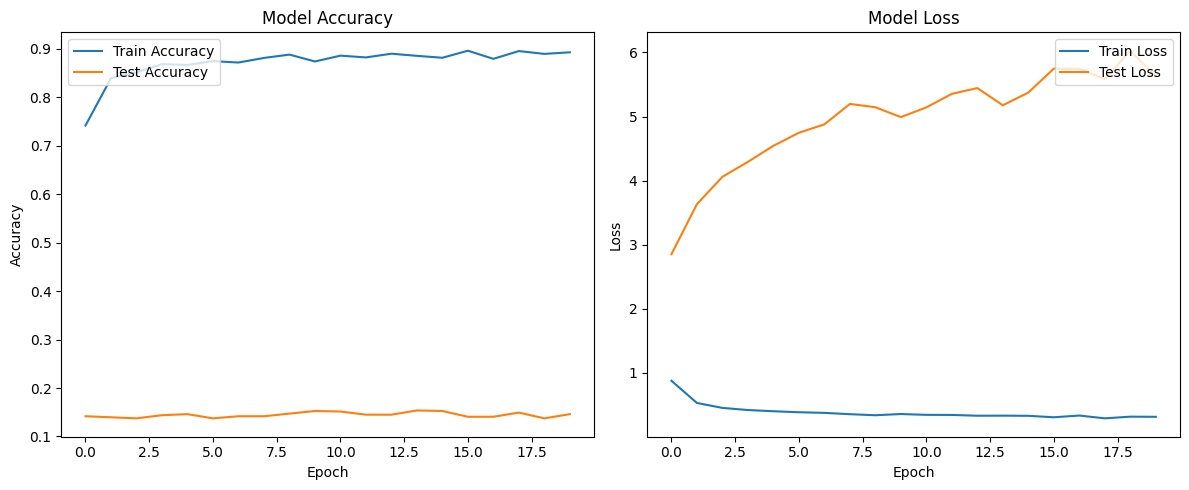

In [18]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot([acc.cpu().numpy() for acc in train_accuracies], label='Train Accuracy')
plt.plot([acc.cpu().numpy() for acc in test_accuracies], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [20]:
print("--- Training Summary ---")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Testing Loss: {test_losses[-1]:.4f}")
print(f"Final Testing Accuracy: {test_accuracies[-1]:.4f}")

--- Training Summary ---
Final Training Loss: 0.3110
Final Training Accuracy: 0.8929
Final Testing Loss: 5.6271
Final Testing Accuracy: 0.1461
